In [38]:
import pandas as pd

In [39]:
data=pd.read_csv(r"C:\Users\BrunoNad\Downloads\jcxq-k9xf.csv")
data

,ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
0,1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
1,2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
2,3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
3,4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
4,5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0
...,...,...,...,...,...,...,...,...,...
73,74.0,Mount Greenwood,1.0,3.4,8.7,4.3,36.8,34381,16.0
74,75.0,Morgan Park,0.8,13.2,15.0,10.8,40.3,27149,30.0
75,76.0,O'Hare,3.6,15.4,7.1,10.9,30.3,25828,24.0
76,77.0,Edgewater,4.1,18.2,9.2,9.7,23.8,33385,19.0


In [40]:
data.isnull().sum()

ca                                             1
community_area_name                            0
percent_of_housing_crowded                     0
percent_households_below_poverty               0
percent_aged_16_unemployed                     0
percent_aged_25_without_high_school_diploma    0
percent_aged_under_18_or_over_64               0
per_capita_income_                             0
hardship_index                                 1
dtype: int64

In [41]:
data=data.dropna()
data

,ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
0,1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
1,2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
2,3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
3,4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
4,5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0
...,...,...,...,...,...,...,...,...,...
72,73.0,Washington Height,1.1,16.9,20.8,13.7,42.6,19713,48.0
73,74.0,Mount Greenwood,1.0,3.4,8.7,4.3,36.8,34381,16.0
74,75.0,Morgan Park,0.8,13.2,15.0,10.8,40.3,27149,30.0
75,76.0,O'Hare,3.6,15.4,7.1,10.9,30.3,25828,24.0


In [18]:
pip install pandasql

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import pandasql as ps

In [43]:
# ispis prvih 5 redaka tablice
ps.sqldf("SELECT * FROM data LIMIT 5",locals())

,ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
0,1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
1,2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
2,3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
3,4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
4,5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0


In [44]:
# problem 1: how many rows are in the dataset?

ps.sqldf("SELECT COUNT(*) FROM data",locals())

,COUNT(*)
0,77


In [45]:
# problem 2: how many community areas in Chicago have a hardship index greater than 50?

ps.sqldf("SELECT COUNT(*) FROM data WHERE hardship_index>50")

,COUNT(*)
0,38


In [46]:
# problem 3: what is the maximum value of hardship index in this dataset?

ps.sqldf("SELECT MAX(hardship_index) FROM data")

,MAX(hardship_index)
0,98.0


In [47]:
# problem 4: which community area which has the highest hardship index?

ps.sqldf("SELECT community_area_name FROM data WHERE hardship_index=(SELECT MAX(hardship_index) FROM data)")

,community_area_name
0,Riverdale


In [48]:
# problem 5: which chicago community areas have per-capita incomes greater than 60 000?

ps.sqldf("SELECT community_area_name FROM data WHERE per_capita_income_>60000")



,community_area_name
0,Lake View
1,Lincoln Park
2,Near North Side
3,Loop


<Axes: xlabel='per_capita_income_', ylabel='hardship_index'>

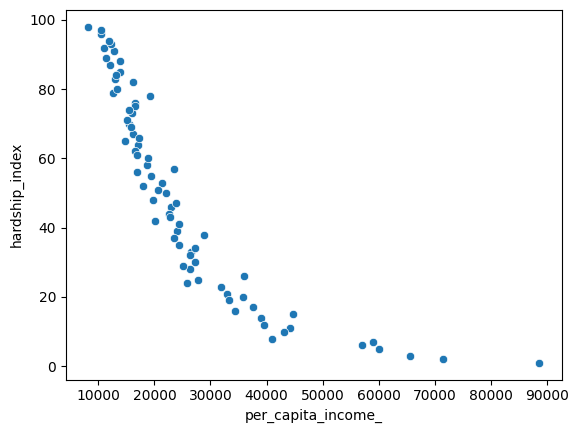

In [49]:
# problem 6: create a scatter plot using variables per_capita_income and hardship_index
# explain the correlation between the two variables

import seaborn as sns

sns.scatterplot(data=data,x="per_capita_income_",y="hardship_index")

In [50]:
from scipy import stats

stats.pearsonr(data['per_capita_income_'],data['hardship_index'])

PearsonRResult(statistic=np.float64(-0.8491674629307857), pvalue=np.float64(1.7257814685298003e-22))